
### Feature Engineering
- Building analysis columns from the cleaned datasets through extraction and field calculations.

**Feature engineering comes after cleaning because:**
Altough cleaned data is *correct*. Engineered features make it *useful for deeper analysis*.
This notebook adds columns that cannot be derived during cleaning because they require
business logic, cross-dataset joins, or statistical transformations.

In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110

BLUE   = "#1f77b4"
GREEN  = "#2ca02c"
ORANGE = "#ff7f0e"
RED    = "#d62728"
PURPLE = "#9467bd"

In [2]:
sales     = pd.read_csv('sales_clean_data.csv',     parse_dates=['date'])
customers = pd.read_csv('customers_clean_data.csv', parse_dates=['first_purchase_date','last_purchase_date'])
products  = pd.read_csv('products_clean_data.csv')
expenses  = pd.read_csv('expenses_clean_data.csv',  parse_dates=['date'])
inventory = pd.read_csv('inventory_clean_data.csv', parse_dates=['date'])

In [15]:
# check the shape for each dataset
print(f"sales: {sales.shape}")
print(f"customers: {customers.shape}")
print(f"products: {products.shape}")
print(f"expenses: {expenses.shape}")
print(f"inventory: {inventory.shape}")

sales: (9989, 19)
customers: (200, 17)
products: (25, 12)
expenses: (1322, 4)
inventory: (13675, 12)


#### check columns for each adataset

In [16]:
print(f"sales:{sales.columns}")

sales:Index(['sale_id', 'date', 'store_channel', 'payment_method', 'product_id',
       'product_name', 'category', 'sub_category', 'quantity_sold',
       'unit_price', 'discount_pct', 'discount_amount', 'total_sale',
       'cost_total', 'gross_profit', 'customer_id', 'is_promotion',
       'is_returned', 'net_profit'],
      dtype='str')


In [17]:
print(f"customers:{customers.columns}")

customers:Index(['customer_id', 'name', 'email', 'age', 'gender', 'city', 'state',
       'segment', 'total_items_purchased', 'total_spent', 'num_orders',
       'last_purchase_date', 'favourite_category', 'first_purchase_date',
       'avg_order_value', 'age_group', 'derived_segment'],
      dtype='str')


In [18]:
print(f"products:{products.columns}")

products:Index(['product_id', 'product_name', 'category', 'sub_category', 'base_price',
       'cost_price', 'season', 'profit_per_unit', 'profit_margin_pct',
       'is_winter', 'is_summer', 'is_all_season'],
      dtype='str')


In [19]:
print(f"expenses:{expenses.columns}")

expenses:Index(['date', 'category', 'amount', 'notes'], dtype='str')


In [20]:
print(f"inventory:{inventory.columns}")

inventory:Index(['date', 'product_id', 'product_name', 'category', 'stock_level',
       'reorder_point', 'supplier', 'unit_cost', 'stock_value', 'stock_change',
       'is_suspect', 'daily_sales'],
      dtype='str')


In [21]:
# general information on each dataset
sales.info()
customers.info()
products.info()
expenses.info()
inventory.info()

<class 'pandas.DataFrame'>
RangeIndex: 9989 entries, 0 to 9988
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   sale_id          9989 non-null   str           
 1   date             9989 non-null   datetime64[us]
 2   store_channel    9989 non-null   str           
 3   payment_method   9989 non-null   str           
 4   product_id       9989 non-null   str           
 5   product_name     9989 non-null   str           
 6   category         9989 non-null   str           
 7   sub_category     9989 non-null   str           
 8   quantity_sold    9989 non-null   int64         
 9   unit_price       9989 non-null   float64       
 10  discount_pct     9989 non-null   int64         
 11  discount_amount  9989 non-null   float64       
 12  total_sale       9989 non-null   float64       
 13  cost_total       9989 non-null   float64       
 14  gross_profit     9989 non-null   float64       
 15

In [22]:
# Time-based features from the transaction date
sales['year']        = sales['date'].dt.year
sales['quarter']     = sales['date'].dt.quarter
sales['month_num']   = sales['date'].dt.month
sales['month_name']  = sales['date'].dt.strftime('%b')
sales['day_of_week'] = sales['date'].dt.day_name()
sales['is_weekend']  = sales['date'].dt.dayofweek >= 5

In [23]:
# days_since_start: distance from the first transaction date
sales['days_since_start'] = (sales['date'] - sales['date'].min()).dt.days

In [24]:
print(sales[['date','year','quarter','month_num','day_of_week','is_weekend','days_since_start']].head())

        date  year  quarter  month_num day_of_week  is_weekend  \
0 2024-01-01  2024        1          1      Monday       False   
1 2024-01-01  2024        1          1      Monday       False   
2 2024-01-01  2024        1          1      Monday       False   
3 2024-01-01  2024        1          1      Monday       False   
4 2024-01-01  2024        1          1      Monday       False   

   days_since_start  
0                 0  
1                 0  
2                 0  
3                 0  
4                 0  


- **Why this is important:** The raw `date` column only supports row-level filtering.
Breaking it into `year`, `quarter`, `month_num`, `day_of_week`, and `is_weekend`
lets us group, pivot, and trend-analyse without re-deriving these every time.

In [25]:
#Transaction-level profit margin %
# gross_profit / total_sale — how much of each sale is profit, before considering returns
# Returns will show 0% because net_profit = 0 for returned rows
sales['profit_margin_pct'] = (sales['net_profit'] / sales['total_sale'] * 100).round(2)

In [26]:
# Revenue per unit — useful to compare effective price across different order sizes
sales['revenue_per_unit'] = (sales['total_sale'] / sales['quantity_sold']).round(2)

In [27]:
print(sales[['total_sale','quantity_sold','net_profit','profit_margin_pct','revenue_per_unit']].head())

   total_sale  quantity_sold  net_profit  profit_margin_pct  revenue_per_unit
0       80.99              1       45.99              56.78             80.99
1       50.99              1       28.99              56.85             50.99
2       40.49              1       25.49              62.95             40.49
3       19.99              1       11.99              59.98             19.99
4       80.99              1       45.99              56.78             80.99


- `profit_margin_pct` at the transaction level is different from the product catalogue margin, 
it reflects the actual margin achieved after discounts and returns on each sale.
`revenue_per_unit` normalises revenue across transactions with different quantities.

In [28]:
# Verify distributions look reasonable
print("profit_margin_pct stats:")
print(sales['profit_margin_pct'].describe().round(2))
print()
print("revenue_per_unit stats:")
print(sales['revenue_per_unit'].describe().round(2))
print()
print("Transactions by quarter:")
print(sales.groupby(['year','quarter']).size().reset_index(name='transactions').to_string(index=False))

profit_margin_pct stats:
count    9989.00
mean       61.35
std        14.57
min         0.00
25%        61.10
50%        63.90
75%        66.66
max        74.97
Name: profit_margin_pct, dtype: float64

revenue_per_unit stats:
count    9989.00
mean       36.04
std        19.34
min         7.99
25%        19.99
50%        33.99
75%        47.49
max        89.99
Name: revenue_per_unit, dtype: float64

Transactions by quarter:
 year  quarter  transactions
 2024        1          1831
 2024        2          1506
 2024        3          1676
 2024        4          1666
 2025        1          1764
 2025        2          1546


In [29]:
sales[sales["profit_margin_pct"] == 0]

,sale_id,date,store_channel,payment_method,product_id,product_name,category,sub_category,quantity_sold,unit_price,...,net_profit,year,quarter,month_num,month_name,day_of_week,is_weekend,days_since_start,profit_margin_pct,revenue_per_unit
27,S00028,2024-01-02,Online,Credit Card,P022,Leather Belt,All,Accessories,3,19.99,...,0.0,2024,1,1,Jan,Tuesday,False,1,0.0,18.99
46,S00047,2024-01-02,Online,Mobile Pay,P020,Unisex Cap,All,Accessories,3,14.99,...,0.0,2024,1,1,Jan,Tuesday,False,1,0.0,14.24
92,S00093,2024-01-03,Online,PayPal,P021,Unisex Socks (3-pack),All,Accessories,3,9.99,...,0.0,2024,1,1,Jan,Wednesday,False,2,0.0,9.49
94,S00095,2024-01-03,Online,Credit Card,P021,Unisex Socks (3-pack),All,Accessories,1,9.99,...,0.0,2024,1,1,Jan,Wednesday,False,2,0.0,8.49
128,S00129,2024-01-04,Physical,Credit Card,P020,Unisex Cap,All,Accessories,2,14.99,...,0.0,2024,1,1,Jan,Thursday,False,3,0.0,13.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9882,S09883,2025-06-25,Physical,Cash,P016,Kids T-shirt,Kids,Shirt,1,14.99,...,0.0,2025,2,6,Jun,Wednesday,False,541,0.0,13.49
9915,S09916,2025-06-27,Physical,Mobile Pay,P022,Leather Belt,All,Accessories,1,19.99,...,0.0,2025,2,6,Jun,Friday,False,543,0.0,19.99
9921,S09922,2025-06-27,Online,Credit Card,P024,Men's Swim Shorts,Men,Swimwear,3,29.99,...,0.0,2025,2,6,Jun,Friday,False,543,0.0,29.99
9976,S09977,2025-06-30,Online,Credit Card,P020,Unisex Cap,All,Accessories,3,14.99,...,0.0,2025,2,6,Jun,Monday,False,546,0.0,14.24


In [30]:
sales[sales["profit_margin_pct"] == 0]["product_name"].value_counts()

product_name
Unisex Cap               42
Leather Belt             38
Canvas Tote Bag          37
Unisex Socks (3-pack)    35
Men's Premium T-shirt    25
Women's Skinny Jeans     25
Men's Basic T-shirt      21
Women's Swimsuit         21
Men's Slim Jeans         21
Women's Skirt            20
Women's Puffer Jacket    19
Women's Floral Dress     18
Men's Swim Shorts        18
Women's Blouse           18
Women's Cardigan         16
Men's Puffer Jacket      16
Men's Hoodie             15
Men's Polo Shirt         14
Women's Hoodie           13
Women's Casual Dress     13
Kids T-shirt             12
Men's Chino Pants        11
Kids Jeans                7
Kids Dress                7
Kids Jacket               2
Name: count, dtype: int64

In [31]:
sales[sales["profit_margin_pct"] == 0]["is_promotion"].value_counts()

is_promotion
False    357
True     127
Name: count, dtype: int64

In [32]:
sales["break_even_sale"] = sales["net_profit"] == 0

In [33]:
sales["break_even_sale"].mean()

np.float64(0.04845329862849134)

In [34]:
sales[sales["profit_margin_pct"] == 0]["discount_pct"].describe()

count    484.000000
mean       5.165289
std        5.904130
min        0.000000
25%        0.000000
50%        5.000000
75%       10.000000
max       20.000000
Name: discount_pct, dtype: float64

In [44]:
sales["profitability"] = pd.cut(
    sales["profit_margin_pct"],
    bins=[-1,0,20,40,60,100],
    labels=["Loss/Break-even","Low","Medium","High","Very High"]
)

In [45]:
sales["profitability"].value_counts()

profitability
Very High          7900
High               1605
Loss/Break-even     484
Low                   0
Medium                0
Name: count, dtype: int64

In [46]:
# Join product-level features onto each sales transaction
# We only bring the columns we need — not the entire products table
product_features = products[['product_id', 'season', 'profit_margin_pct', 'is_winter', 'is_summer', 'cost_price']]
product_features = product_features.rename(columns={'profit_margin_pct': 'catalogue_margin_pct'})

sales = sales.merge(product_features, on='product_id', how='left')

In [50]:
# Verify the join — all rows should have a season tag
missing_season = sales['season'].isna().sum()
print(f"Transactions with no season tag after join: {missing_season}")
print()
print("Season distribution across transactions:")
print(sales['season'].value_counts().to_string())

Transactions with no season tag after join: 0

Season distribution across transactions:
season
All       6233
Summer    1888
Winter    1868


In [51]:
# Check: catalogue_margin_pct vs realised profit_margin_pct
# The gap tells us how much discounts and returns erode the catalogue margin in practice
sales['margin_erosion'] = (sales['catalogue_margin_pct'] - sales['profit_margin_pct']).round(2)

print("Margin erosion (catalogue margin minus realised margin):")
print(sales['margin_erosion'].describe().round(2))
print()

Margin erosion (catalogue margin minus realised margin):
count    9989.00
mean        5.16
std        14.08
min        -0.05
25%         0.01
50%         1.80
75%         4.01
max        75.00
Name: margin_erosion, dtype: float64



In [52]:
print("Avg margin erosion by discount tier:")
print(sales.groupby('discount_pct')['margin_erosion'].mean().round(2).to_string())

Avg margin erosion by discount tier:
discount_pct
0      3.37
5      4.73
10     6.61
15     8.96
20    10.87


- Each transaction now carries the product's catalogue margin alongside the actual realised margin. margin_erosion quantifies exactly how much each discount tier and return costs in margin points.

#### Customers-RFM Scoring
- **RFM (Recency, Frequency, Monetary)** is the standard retail customer value framework.
It scores each customer on three dimensions:

- **Recency** ~ how recently did they purchase? (lower days = better)
- **Frequency** ~ how many orders have they placed? (higher = better)
- **Monetary** ~ how much have they spent in total? (higher = better)

Each dimension is scored 1–4 using quartiles (4 = best).

Combined RFM score (3–12) maps to a customer segment: Champion, Loyal, Potential, At Risk, or Lost.

 - RFM is behaviour-based and forward-looking, it identifies customers about to churn
(high M, high F, but low R = was valuable but hasn't bought recently).

In [53]:
# Reference date: one day after the last transaction in the dataset
# Using the dataset end date rather than today ensures reproducibility
reference_date = pd.Timestamp('2025-07-01')

# Recency: days since last purchase (lower = more recent = better)
customers['recency_days'] = (reference_date - customers['last_purchase_date']).dt.days

# Tenure: days from first to last purchase — measures loyalty window
customers['tenure_days'] = (customers['last_purchase_date'] - customers['first_purchase_date']).dt.days


In [54]:
print(customers[['customer_id','first_purchase_date','last_purchase_date','recency_days','tenure_days']].head())

  customer_id first_purchase_date last_purchase_date  recency_days  \
0        C001          2024-01-29         2025-06-18            13   
1        C002          2024-01-03         2025-06-25             6   
2        C003          2024-01-12         2025-06-20            11   
3        C004          2024-01-06         2025-06-26             5   
4        C005          2024-01-09         2025-06-23             8   

   tenure_days  
0          506  
1          539  
2          525  
3          537  
4          531  


In [55]:
# Score each RFM dimension into quartiles (1-4)
# Recency: lower days = better, so we reverse the ranking (rank ascending=False)
# Frequency and Monetary: higher = better, rank ascending=True

# R score: rank recency_days descending (most recent = rank 1 = score 4)
customers['R_score'] = pd.qcut(customers['recency_days'].rank(method='first', ascending=True),
                                q=4, labels=[4, 3, 2, 1]).astype(int)

# F score: rank num_orders ascending (most orders = highest score)
customers['F_score'] = pd.qcut(customers['num_orders'].rank(method='first'),
                                q=4, labels=[1, 2, 3, 4]).astype(int)

# M score: rank total_spent ascending (highest spend = highest score)
customers['M_score'] = pd.qcut(customers['total_spent'].rank(method='first'),
                                q=4, labels=[1, 2, 3, 4]).astype(int)

# Combined RFM score (3-12)
customers['RFM_score'] = customers['R_score'] + customers['F_score'] + customers['M_score']

In [56]:
print("RFM scores calculated.")
print(customers[['customer_id','recency_days','num_orders','total_spent',
                  'R_score','F_score','M_score','RFM_score']].head(10).to_string(index=False))

RFM scores calculated.
customer_id  recency_days  num_orders  total_spent  R_score  F_score  M_score  RFM_score
       C001            13          57      3108.42        2        4        3          9
       C002             6          67      6903.24        3        4        4         11
       C003            11          43      2501.08        2        1        1          4
       C004             5          48      2777.74        3        2        2          7
       C005             8          60      3634.30        2        4        3          9
       C006             8          53      2708.72        2        3        1          6
       C007             2          40      2642.09        4        1        1          6
       C008             3          61      5549.68        4        4        4         12
       C009             4          54      2941.64        3        3        2          8
       C010            17          61      3681.88        2        4        3          

In [57]:
# Map RFM score to business segment
# These thresholds are standard retail RFM benchmarks
rfm_segment_map = {
    12: 'Champion',
    11: 'Champion',
    10: 'Loyal',
    9:  'Loyal',
    8:  'Potential',
    7:  'Potential',
    6:  'At Risk',
    5:  'At Risk',
    4:  'Lost',
    3:  'Lost'
}
customers['RFM_segment'] = customers['RFM_score'].map(rfm_segment_map)

In [58]:
print(customers['RFM_segment'].value_counts().to_string())
print()
print("Avg metrics by RFM segment:")
print(customers.groupby('RFM_segment').agg(
    count        = ('customer_id', 'count'),
    avg_recency  = ('recency_days', 'mean'),
    avg_orders   = ('num_orders', 'mean'),
    avg_spent    = ('total_spent', 'mean')
).round(1).to_string())

RFM_segment
Loyal        66
Potential    54
At Risk      42
Lost         26
Champion     12

Avg metrics by RFM segment:
             count  avg_recency  avg_orders  avg_spent
RFM_segment                                           
At Risk         42         13.6        45.4     2693.3
Champion        12          3.2        63.9     5026.6
Lost            26         25.2        41.8     2320.9
Loyal           66          6.2        53.6     3910.6
Potential       54         13.3        49.9     3337.5


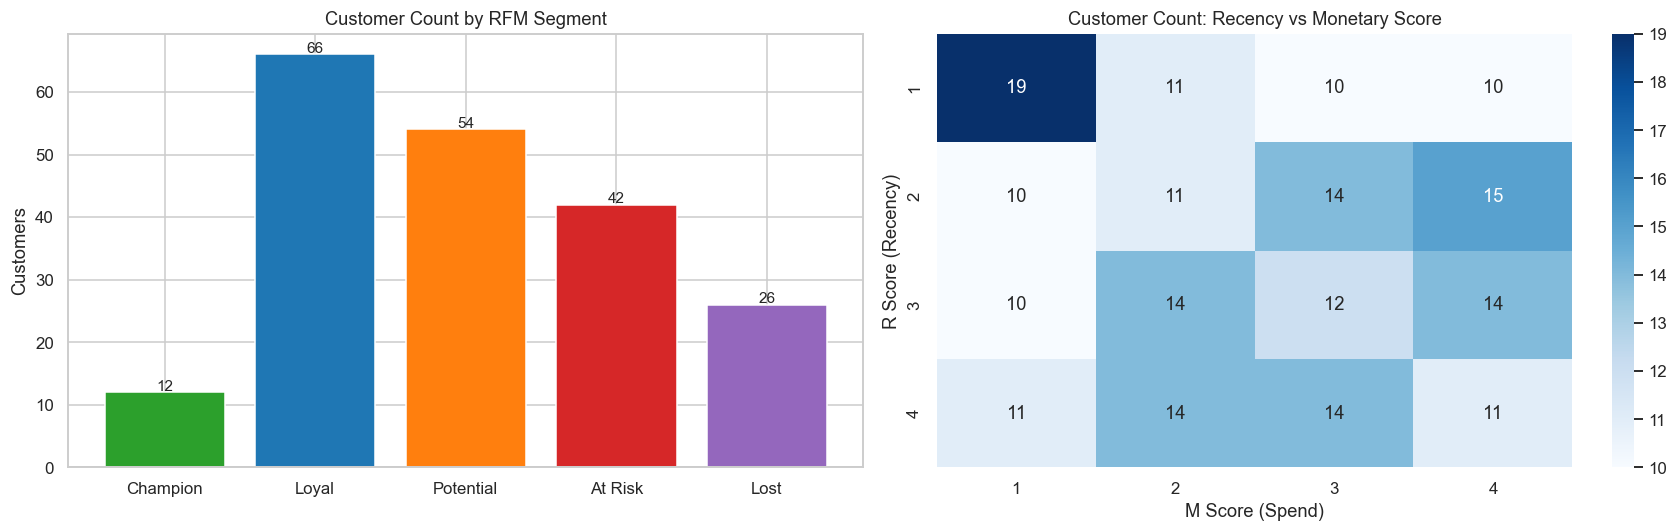

In [59]:
# Visualise RFM segment distribution and score heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

seg_order = ['Champion', 'Loyal', 'Potential', 'At Risk', 'Lost']
seg_counts = customers['RFM_segment'].value_counts().reindex(seg_order)
colors = [GREEN, BLUE, ORANGE, RED, PURPLE]

axes[0].bar(seg_counts.index, seg_counts.values, color=colors)
axes[0].set_title("Customer Count by RFM Segment")
axes[0].set_ylabel("Customers")
for bar, val in zip(axes[0].patches, seg_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', fontsize=10)

# R vs M score heatmap — shows whether recency and monetary value are correlated
rfm_pivot = customers.groupby(['R_score','M_score']).size().reset_index(name='count')
rfm_heatmap = rfm_pivot.pivot(index='R_score', columns='M_score', values='count').fillna(0)
sns.heatmap(rfm_heatmap, annot=True, fmt='.0f', cmap='Blues', ax=axes[1])
axes[1].set_title("Customer Count: Recency vs Monetary Score")
axes[1].set_xlabel("M Score (Spend)")
axes[1].set_ylabel("R Score (Recency)")

plt.tight_layout()
plt.show()

Every customer now has an **RFM_segment** label grounded in actual purchase behaviour.

- Champions (score 10–12): bought recently, buy often, spend most → reward and retain.
- Loyal (score 8–9): consistent buyers, strong spend → upsell and cross-sell.
- Potential (score 6–7): moderate engagement → nurture with targeted campaigns.
- At Risk (score 4–5): used to buy but recency has dropped → win-back campaigns needed.
- Lost (score 3): haven't bought recently, low frequency → low ROI to reactivate.

The **R vs M heatmap** shows whether StyleSense's highest spenders are still buying recently — if they cluster in low-R cells, there is a churn problem among the most valuable customers.

#### Stock Health & Days Until Stockout

In [60]:
# Stock health ratio: current stock vs reorder point
# > 1.0  = safe (above reorder threshold)
# = 1.0  = at reorder threshold — order now
# < 1.0  = critical (already below reorder threshold)
inventory['stock_health'] = (inventory['stock_level'] / inventory['reorder_point']).round(2)

# Near-stockout boolean flag
inventory['is_near_stockout'] = inventory['stock_level'] <= inventory['reorder_point']

In [61]:
print("Stock health summary:")
print(inventory['stock_health'].describe().round(2))
print()
print(f"Near-stockout records: {inventory['is_near_stockout'].sum():,} "
      f"({inventory['is_near_stockout'].mean()*100:.1f}% of all records)")

Stock health summary:
count    13675.00
mean         2.63
std          1.00
min          1.00
25%          1.78
50%          2.55
75%          3.35
max          5.00
Name: stock_health, dtype: float64

Near-stockout records: 96 (0.7% of all records)


In [62]:
# Days until stockout: stock_level divided by 7-day rolling avg daily sales
# We use a rolling average rather than instantaneous daily_sales to smooth out
# zero-sale days (days where no sales were recorded for that product)
inventory = inventory.sort_values(['product_id', 'date']).reset_index(drop=True)

inventory['rolling_avg_sales'] = (
    inventory.groupby('product_id')['daily_sales']
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

# Avoid division by zero: if rolling avg is 0, set days_until_stockout to a large number (999)
# meaning no near-term risk based on observed sales pace
inventory['days_until_stockout'] = inventory.apply(
    lambda row: round(row['stock_level'] / row['rolling_avg_sales'], 1)
    if row['rolling_avg_sales'] > 0 else 999,
    axis=1
)

In [63]:
print(inventory[['product_name','date','stock_level','rolling_avg_sales','days_until_stockout']].head(10).to_string(index=False))

       product_name       date  stock_level  rolling_avg_sales  days_until_stockout
Men's Basic T-shirt 2024-01-01          200           0.000000                999.0
Men's Basic T-shirt 2024-01-02          199           0.500000                398.0
Men's Basic T-shirt 2024-01-03          195           1.666667                117.0
Men's Basic T-shirt 2024-01-04          195           1.250000                156.0
Men's Basic T-shirt 2024-01-05          195           1.000000                195.0
Men's Basic T-shirt 2024-01-06          195           0.833333                234.0
Men's Basic T-shirt 2024-01-07          192           1.142857                168.0
Men's Basic T-shirt 2024-01-08          187           1.857143                100.7
Men's Basic T-shirt 2024-01-09          187           1.714286                109.1
Men's Basic T-shirt 2024-01-10          184           1.571429                117.1


In [65]:
#Summarise by product: avg days until stockout and avg stock health
inventory_summary = inventory.groupby(['product_id','product_name','category']).agg(
    avg_stock_health     = ('stock_health', 'mean'),
    min_stock_health     = ('stock_health', 'min'),
    near_stockout_days   = ('is_near_stockout', 'sum'),
    avg_days_to_stockout = ('days_until_stockout', 'mean')
).reset_index()

inventory_summary['avg_stock_health']     = inventory_summary['avg_stock_health'].round(2)
inventory_summary['avg_days_to_stockout'] = inventory_summary['avg_days_to_stockout'].round(1)
inventory_summary = inventory_summary.sort_values('avg_stock_health')

print("Inventory Health by Product (sorted by most at-risk):")
print(inventory_summary.to_string(index=False))

Inventory Health by Product (sorted by most at-risk):
product_id          product_name category  avg_stock_health  min_stock_health  near_stockout_days  avg_days_to_stockout
      P004     Men's Chino Pants      Men              2.39              1.00                   4                 101.7
      P006   Men's Puffer Jacket      Men              2.41              1.00                   1                 201.3
      P020            Unisex Cap      All              2.42              1.00                   7                  57.9
      P012  Women's Skinny Jeans    Women              2.44              1.02                   0                 116.3
      P021 Unisex Socks (3-pack)      All              2.44              1.00                   2                  56.6
      P015      Women's Cardigan    Women              2.50              1.00                  11                 221.1
      P014 Women's Puffer Jacket    Women              2.52              1.00                   1         

- **stock_health**: ratio of current stock to reorder point, a value of 1.0 means you are exactly at the threshold; below 1.0 means you are already below the reorder point.
- **is_near_stockout**: boolean flag, simpler to filter than computing the ratio each time.
- **days_until_stockout**: estimates how many days of stock remain based on the rolling average daily sales rate, a forward-looking metric that powers prescriptive recommendations.

####  Expenses: Fixed vs Variable Classification & Time Features

- **P&L** analysis requires separating fixed costs (unavoidable regardless of sales volume) from variable costs (which scale with revenue). Without this flag, every expense analysis treats Rent and COGS as equivalent — they are not.

- **Fixed costs** must be covered even in a zero-revenue month. **Variable costs** can theoretically be reduced if sales fall.

In [66]:
# Classify each expense category as fixed or variable
# Fixed: same amount every month regardless of revenue
# Variable: amount changes with sales activity
fixed_categories = ['Rent', 'Insurance', 'Software & Subscriptions']
variable_categories = ['Cost of Goods Sold', 'Marketing', 'Payroll', 'Utilities']

expenses['is_fixed_cost'] = expenses['category'].isin(fixed_categories)
expenses['cost_type']     = expenses['is_fixed_cost'].map({True: 'Fixed', False: 'Variable'})

# Time features for grouping
expenses['year']      = expenses['date'].dt.year
expenses['month_num'] = expenses['date'].dt.month
expenses['quarter']   = expenses['date'].dt.quarter

In [67]:
print(expenses.groupby('cost_type')['amount'].agg(['sum','mean','count']).round(2).to_string())
print()
print("Category classification:")
print(expenses.groupby(['category','cost_type'])['amount'].sum().round(2).reset_index().to_string(index=False))

                 sum     mean  count
cost_type                           
Fixed       72900.00  1350.00     54
Variable   474579.42   374.27   1268

Category classification:
                category cost_type    amount
      Cost of Goods Sold  Variable 249989.00
               Insurance     Fixed   7200.00
               Marketing  Variable  15064.49
                 Payroll  Variable 187300.32
                    Rent     Fixed  63000.00
    Shipping & Packaging  Variable  15870.57
Software & Subscriptions     Fixed   2700.00
               Utilities  Variable   6355.04


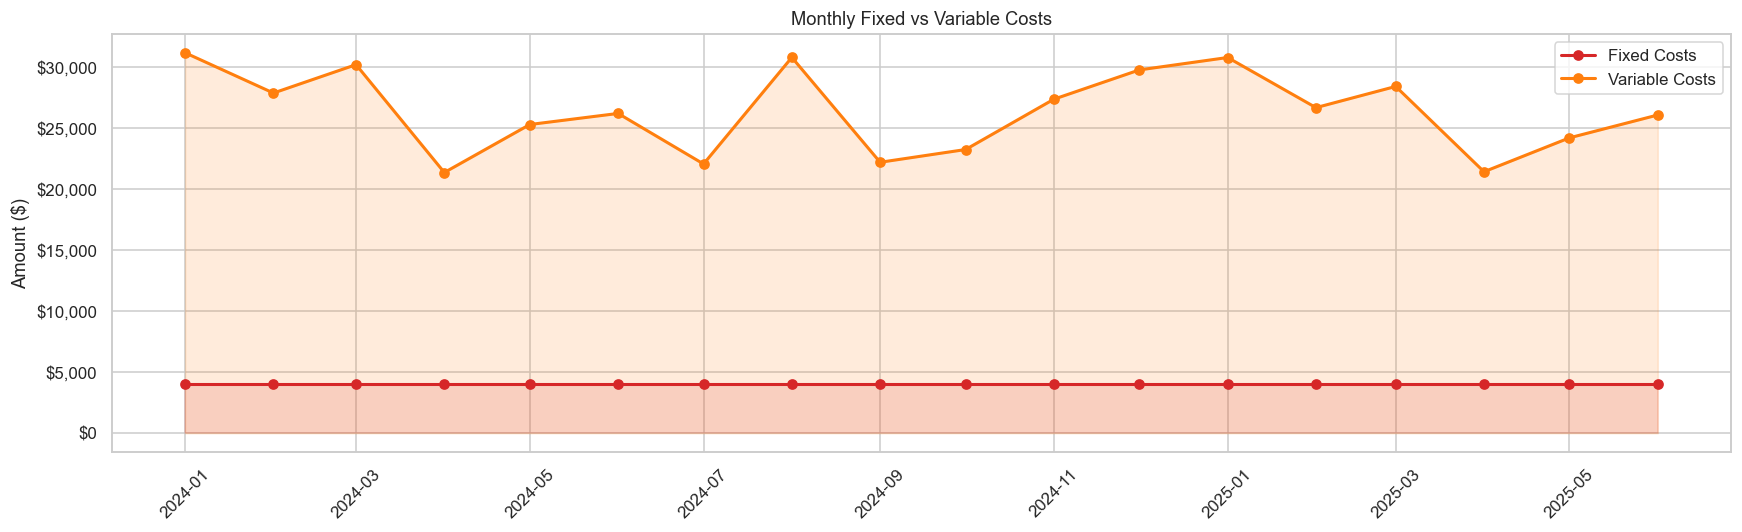

In [68]:
# Monthly fixed vs variable cost trend
monthly_cost_type = expenses.groupby(['date', 'cost_type'])['amount'].sum().reset_index()

# Aggregate to month level
monthly_cost_type['month'] = monthly_cost_type['date'].dt.to_period('M')
monthly_pivot = monthly_cost_type.groupby(['month','cost_type'])['amount'].sum().reset_index()
monthly_pivot['month_dt'] = monthly_pivot['month'].dt.to_timestamp()

fixed_data    = monthly_pivot[monthly_pivot['cost_type'] == 'Fixed']
variable_data = monthly_pivot[monthly_pivot['cost_type'] == 'Variable']

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(fixed_data['month_dt'],    fixed_data['amount'],    label='Fixed Costs',    color=RED,  marker='o', linewidth=2)
ax.plot(variable_data['month_dt'], variable_data['amount'], label='Variable Costs', color=ORANGE, marker='o', linewidth=2)
ax.fill_between(fixed_data['month_dt'],    fixed_data['amount'],    alpha=0.15, color=RED)
ax.fill_between(variable_data['month_dt'], variable_data['amount'], alpha=0.15, color=ORANGE)
ax.set_title("Monthly Fixed vs Variable Costs")
ax.set_ylabel("Amount ($)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Fixed costs should form a flat baseline in the chart. If they spike, that signals a one-off cost or billing anomaly. Variable costs should track sales volume, high-revenue months should have higher variable costs (more COGS, more marketing). If variable costs are rising faster than revenue, margin is being compressed.



In [69]:
# Save all enriched datasets after feature engineering
sales.to_csv('sales_featured.csv', index=False)
customers.to_csv('customers_featured.csv', index=False)
expenses.to_csv('expenses_featured.csv', index=False)
inventory.to_csv('inventory_featured.csv', index=False)

# Products has no new columns beyond cleaning — save under consistent naming
products.to_csv('products_featured.csv', index=False)

In [70]:
print(f"  sales_featured.csv     : {sales.shape}    columns: {list(sales.columns)}")
print()
print(f"  customers_featured.csv : {customers.shape}  columns: {list(customers.columns)}")
print()
print(f"  products_featured.csv  : {products.shape}   columns: {list(products.columns)}")
print()
print(f"  expenses_featured.csv  : {expenses.shape}  columns: {list(expenses.columns)}")
print()
print(f"  inventory_featured.csv : {inventory.shape} columns: {list(inventory.columns)}")

  sales_featured.csv     : (9989, 36)    columns: ['sale_id', 'date', 'store_channel', 'payment_method', 'product_id', 'product_name', 'category', 'sub_category', 'quantity_sold', 'unit_price', 'discount_pct', 'discount_amount', 'total_sale', 'cost_total', 'gross_profit', 'customer_id', 'is_promotion', 'is_returned', 'net_profit', 'year', 'quarter', 'month_num', 'month_name', 'day_of_week', 'is_weekend', 'days_since_start', 'profit_margin_pct', 'revenue_per_unit', 'break_even_sale', 'profitability', 'season', 'catalogue_margin_pct', 'is_winter', 'is_summer', 'cost_price', 'margin_erosion']

  customers_featured.csv : (200, 24)  columns: ['customer_id', 'name', 'email', 'age', 'gender', 'city', 'state', 'segment', 'total_items_purchased', 'total_spent', 'num_orders', 'last_purchase_date', 'favourite_category', 'first_purchase_date', 'avg_order_value', 'age_group', 'derived_segment', 'recency_days', 'tenure_days', 'R_score', 'F_score', 'M_score', 'RFM_score', 'RFM_segment']

  products_f